# DKIST/DL-NIRSP Level 1 Dataset Example
for Arm 3 Fe I 1565 nm

In [1]:
import dkist
import astropy.units as u

from sunpy.net import Fido, attrs as a
import sunpy.map
from astropy.time import Time

from scipy.interpolate import griddata

from glob import glob
import numpy as np
import matplotlib.pyplot as plt

In [2]:
## Change these to reflect your data directory and the dataset ID for the dataset that you want to work with
datadir = '/Users/sjaeggli/Projects/Data/DKIST/data2114'
recid = 'ROGALI'

## Read in the tiled dataset

In [3]:
## Find ASDF file
asdf_file = glob('{:}/{:}/*.asdf'.format(datadir, recid))

## Load DKIST tiled dataset
tds = dkist.load_dataset(asdf_file)

## Explore the dataset

In [4]:
tds

This DL-NIRSP Dataset is an array of (29, 13) Dataset objects and
consists of 1508 frames.
Files are stored in /Users/sjaeggli/Projects/Data/DKIST/data2114/ROGALI

This calibration has Dataset ID ROGALI.
The unique identifier for the input observe frames (Product ID) is L1-RWEJL.

Each Dataset has 4 pixel and 4 world dimensions.

The data are represented by a <class 'dask.array.core.Array'> object:
dask.array<load_files, shape=(4, 247, 68, 54), dtype=float32, chunksize=(1, 247, 68, 54), chunktype=numpy.ndarray>

Array Dim  Axis Name                  Data size  Bounds
        0  polarization state                 4  None
        1  dispersion axis                  247  None
        2  helioprojective latitude          68  None
        3  helioprojective longitude         54  None

World Dim  Axis Name                  Physical Type                   Units
        3  stokes                     phys.polarization.stokes        unknown
        2  wavelength                 em.wl            

In [5]:
## Get number of X and Y tiles in tiled dataset
## Note that x,y ordering of the tiles is reversed from the python array convention
nXtiles,nYtiles = tds.shape

## Get the dimensions of each tile
nS,nW,nY,nX = tds[0,0].data.shape

## Make a summary
print('Number of X Tiles:', nXtiles)
print('Number of Y Tiles:', nYtiles)
print('Axis names:', tds[0,0].wcs.pixel_axis_names) #these are listed in reverse order with respect to indexing in python
print('Number of Stokes Parameters:', nS)
print('Number of Wavelength Pixels:', nW)
print('Number of Spatial Y Pixels:', nY)
print('Number of Spatial X Pixels:', nX)
print('Waveband:', tds[0,0].headers[0]['WAVEBAND'])

Number of X Tiles: 29
Number of Y Tiles: 13
Axis names: ('helioprojective longitude', 'helioprojective latitude', 'dispersion axis', 'polarization state')
Number of Stokes Parameters: 4
Number of Wavelength Pixels: 247
Number of Spatial Y Pixels: 68
Number of Spatial X Pixels: 54
Waveband: Fe I (1565.0 nm)


In [6]:
xt0 = int(nXtiles/2)
yt0 = int(nYtiles/2)
x0 = int(nX/4)
y0 = int(nY/4)
w0 = 80 #spectral pixel in the blue wing of Stokes V profile

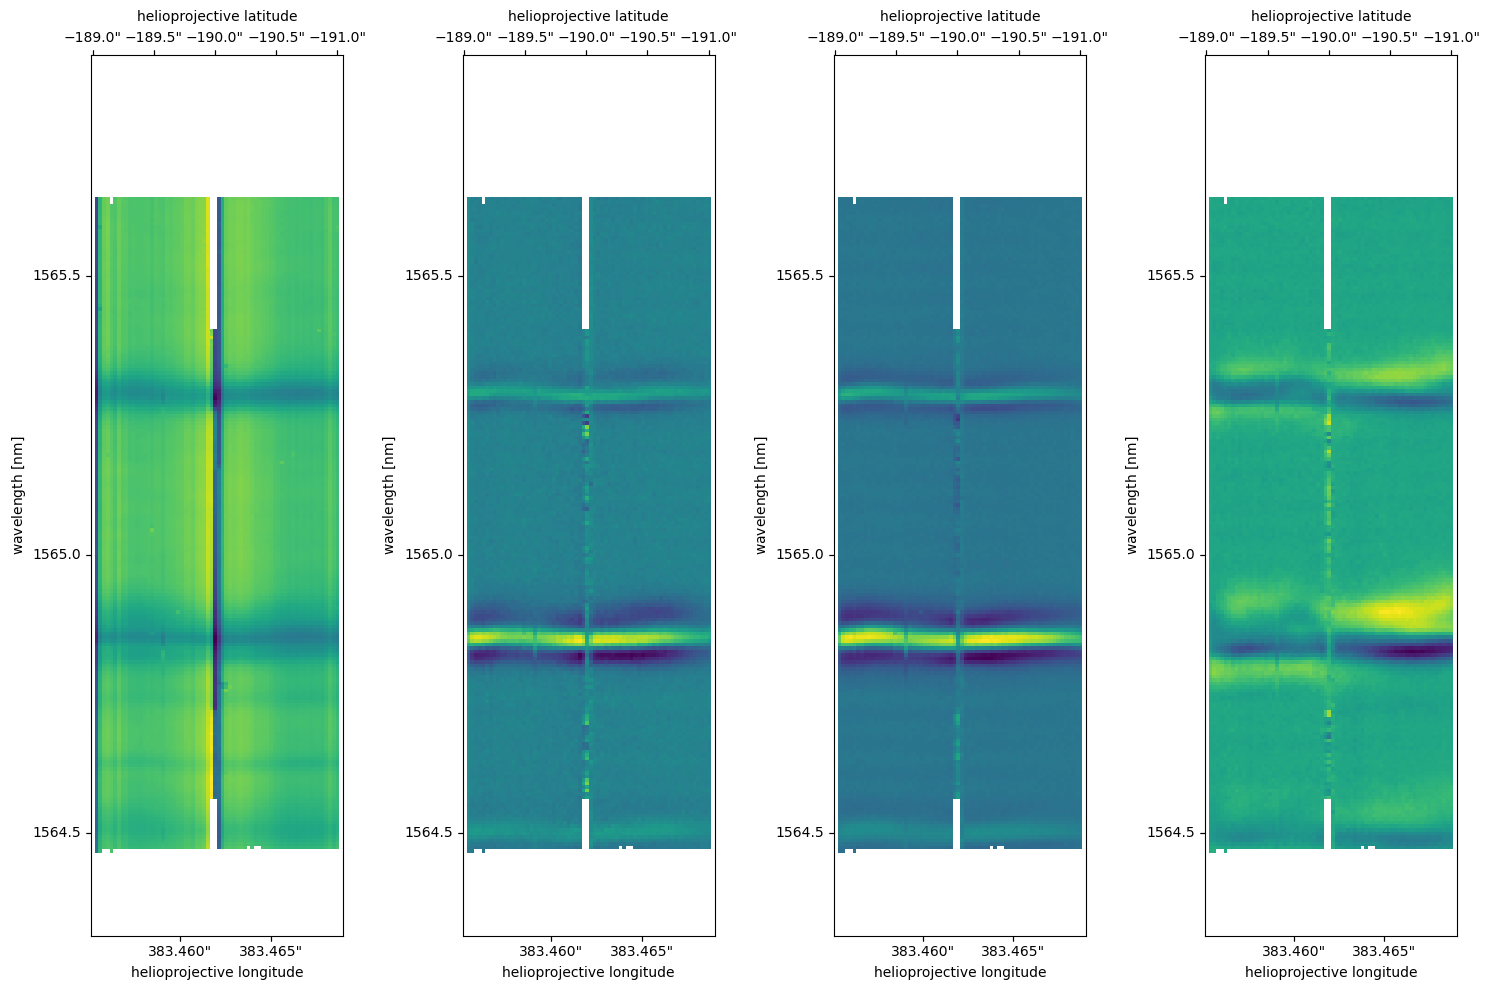

In [7]:
## Show the Stokes spectra from a single tile, taking a slice in the x-direction
fig = plt.figure(figsize=(15,10))

for iS in range(0,nS):
    ax = fig.add_subplot(1,4,iS+1, projection=tds[xt0,yt0][iS,:,:,x0])
    tds[xt0,yt0][iS,:,:,x0].plot(axes=ax, aspect='auto')

plt.tight_layout()
plt.show()

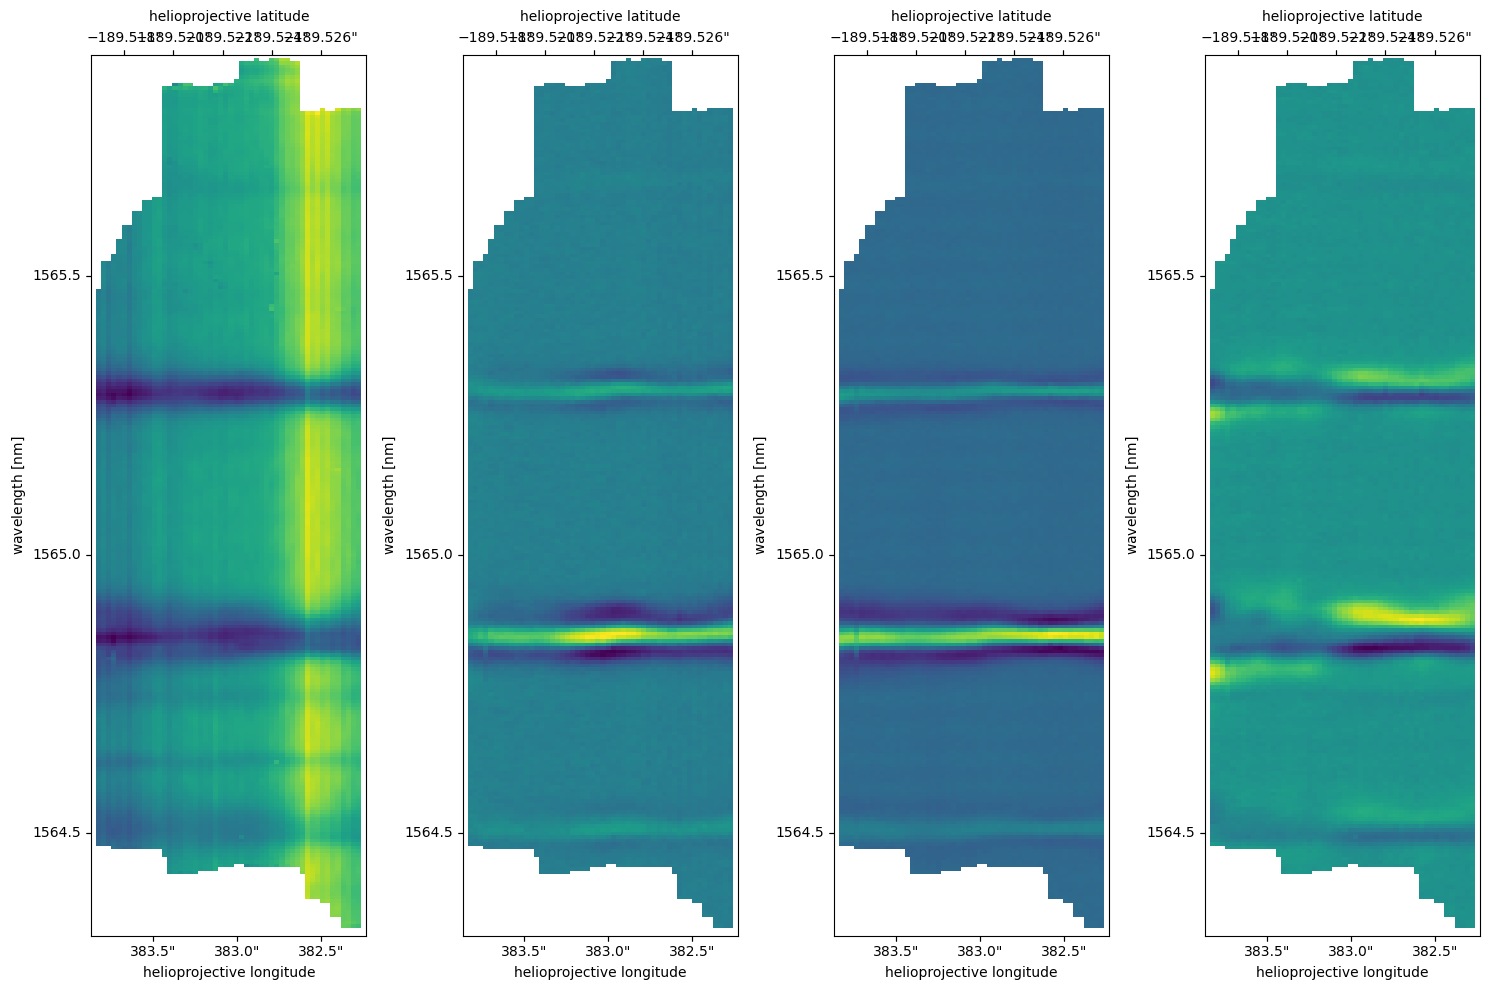

In [8]:
## Show the Stokes spectra from a single tile, taking a slice in the y-direction
fig = plt.figure(figsize=(15,10))

for iS in range(0,nS):
    ax = fig.add_subplot(1,4,iS+1, projection=tds[xt0,yt0][iS,:,y0,:])
    tds[xt0,yt0][iS,:,y0,:].plot(axes=ax, aspect='auto')

plt.tight_layout()
plt.show()

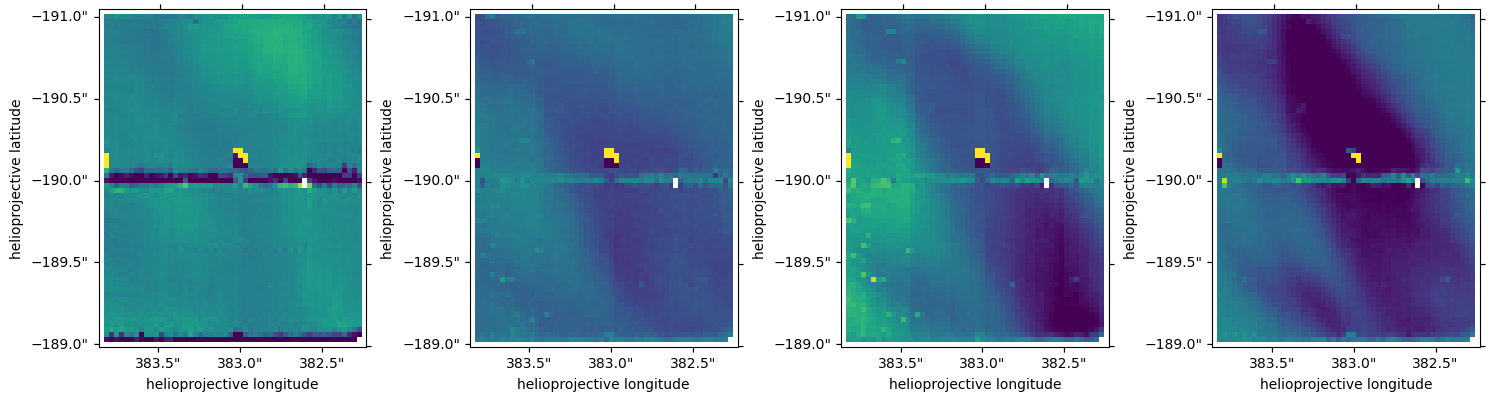

In [9]:
## Show the Stokes image from a single tile, taking a slice in the wavelength-direction
fig = plt.figure(figsize=(15,5))

for iS in range(0,nS):
    if iS == 0:
        vran = (0.5,1.1)
    else:
        vran = (-0.05,0.05)
        
    ax = fig.add_subplot(1,4,iS+1, projection=tds[xt0,yt0][iS,w0,:,:])
    tds[xt0,yt0][iS,w0,:,:].plot(axes=ax, aspect='equal', vmin=vran[0], vmax=vran[1])

plt.tight_layout()
plt.show()

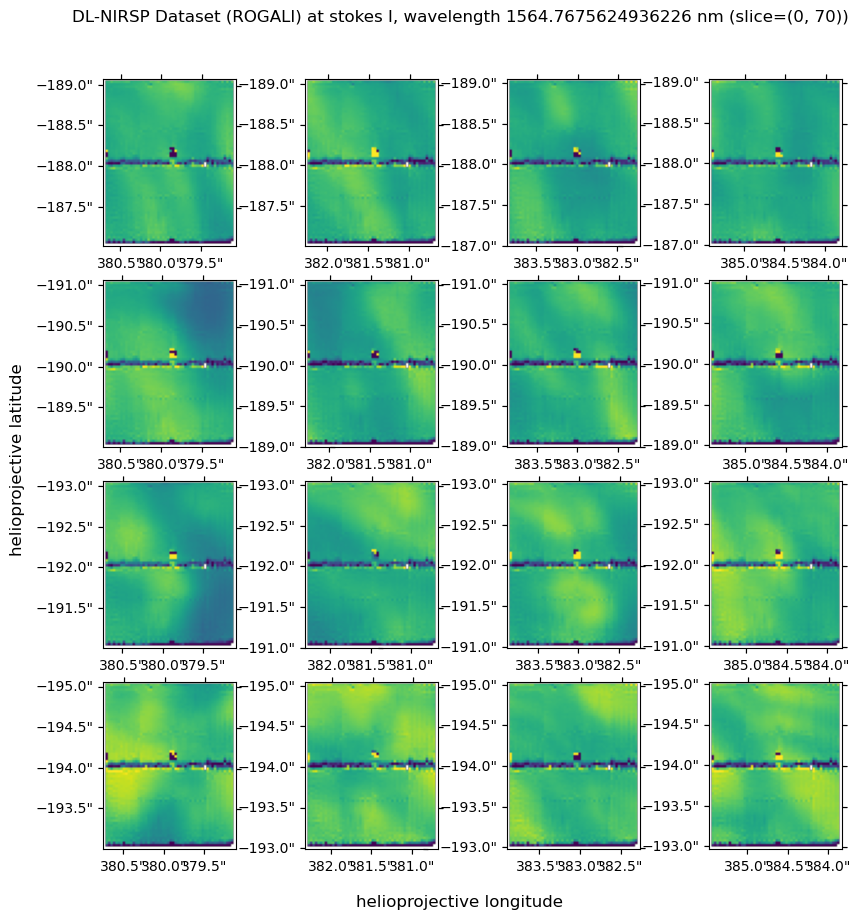

In [10]:
## Show a the same slice in wavelength over several tiles, showing all the mosaic tiles is possible, but takes more time
fig = plt.figure(figsize=(10,10))
tds[xt0-2:xt0+2,yt0-2:yt0+2].plot(slice_index=(0,70), share_zscale=True, vmin=0.5, vmax=1.1)
plt.show()

Notice in this figure, that the run of position values on the x and y axes are reversed with respect to the order that the tiles are in.

## Regridding DL-NIRSP data the DKIST way, with Reproject

In [11]:
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd
from reproject import reproject_interp

from ndcube import NDCube

In [ ]:
w0tiles = tds.slice_tiles[0,w0,:,:]

In [ ]:
reference_wcs, shape_out = find_optimal_celestial_wcs(
    [f.wcs for f in w0tiles.flat],
    auto_rotate=True,
    # We drop the output resolution to reduce memory usage
    # remove this line to run at the native resolution of the input data
    resolution=0.15*u.arcsec,
)

# Due to a bug in reproject we need to reverse the direction of the longitude axis
# https://github.com/astropy/reproject/issues/431
reference_wcs.wcs.cdelt[0] = -reference_wcs.wcs.cdelt[0]

In [ ]:
arr, footprint = reproject_and_coadd(
    w0tiles.flat,
    reference_wcs,
    reproject_function=reproject_interp,
    shape_out=shape_out,
    roundtrip_coords=False,
)

In [ ]:
plt.figure(figsize=(10,10))
stitched = NDCube(arr, reference_wcs)
stitched.plot(vmin=0.5, vmax=1.1, aspect='equal')
plt.show()

Not very pretty.  We'll see about clearing up missing data and residual calibration issues in subsequent notebooks.

## Determining the scan order from metadata

In [ ]:
## Get all the coordinate information for a single tile
coords,wavel,stks = tds[xt0,yt0].axis_world_coords()

In [ ]:
coords

In [ ]:
wavel

In [ ]:
stks

In [ ]:
tds[xt0,yt0].headers

If we compare the obstime in the SkyCoord array above, it looks like it is the mid-time between DATE-BEG and DATE-END values that we see in the header, so that's good.

In [ ]:
tile_time = list()
tile_Tx = list()
tile_Ty = list()

for xti in range(0,nXtiles):
    for yti in range(0,nYtiles):
        coords, = tds[xti,yti][0,w0,:,:].axis_world_coords()
        
        tile_time.append(coords.obstime)
        tile_Tx.append(coords.Tx.mean().value)
        tile_Ty.append(coords.Ty.mean().value)

tile_time = np.array(tile_time)
tile_Tx = np.array(tile_Tx)
tile_Ty = np.array(tile_Ty)

In [ ]:
## sort the coordinates using the time array
sidx = np.argsort(tile_time)

In [ ]:
plt.plot(tile_Tx[sidx],tile_Ty[sidx], color='black')
plt.scatter(tile_Tx[sidx],tile_Ty[sidx], c=np.arange(nXtiles*nYtiles), cmap='rainbow')

plt.xlabel('Average Tile Center Tx [arcsec]')
plt.ylabel('Average Tile Center Ty [arcsec]')

plt.show()

## Ad Hoc Flat Field using local quiet Sun
Correct the mosaic using a flatfield made from the quiet sun tiles

In [ ]:
## Make a coarse map using the average intensity for each mosaic tile
minimap_I = np.zeros([nYtiles,nXtiles])

for yi in range(0,nYtiles):
    for xi in range(0,nXtiles):
        minimap_I[yi,xi] = np.nanmean(tds[xi,yi].data[0,:,:,:]) #stokes I continuum

In [ ]:
## Use the minimap to define a mask for the tiled dataset
thresh_qs = 0.9
mask_qs = (minimap_I > thresh_qs).transpose() #transpose mask to apply to tiled dataset

plt.imshow(minimap_I, origin='lower', vmin=0.5, vmax=1.1)
plt.contour(minimap_I, levels=[thresh_qs], colors=['red'])

plt.show()

In [ ]:
## Make an average tile from all the Stokes I quiet Sun tiles
## Average over the spectral dimension, leaving just the two spatial dimensions for each tile
avg_tile = np.zeros([nY,nX])
count = 0

for ds in tds[mask_qs]:
    avg_tile += np.nanmean(ds.data[0,:,:,:].compute(), axis=0)
    count += 1

avg_tile /= count

In [ ]:
#show the average tile
plt.imshow(avg_tile, origin='lower', vmin=0.5, vmax=1.2)
plt.show()

## Make a basic quicklook
Use the ad hoc flat field to correct the data

In [ ]:
## Calculate the quicklook metrics and extract the world coordinates
## for every spatial pixel in the dataset
cont_w0,cont_w1 = (50, 60)
line_w0,line_w1 = (60, 80)

dl_Tx = np.zeros([nXtiles,nYtiles,nY,nX])
dl_Ty = np.zeros([nXtiles,nYtiles,nY,nX])
dl_cont = np.zeros([nXtiles,nYtiles,nY,nX])
dl_stkv = np.zeros([nXtiles,nYtiles,nY,nX])

for iXt in range(0,nXtiles):
    for iYt in range(0,nYtiles):
        ds = tds[iXt,iYt]

        dl_coord, = ds[0,0,:,:].axis_world_coords()
        dl_Tx[iXt,iYt,:,:] = dl_coord.Tx.value
        dl_Ty[iXt,iYt,:,:] = dl_coord.Ty.value
        
        dl_cont[iXt,iYt,:,:] = np.nanmean(ds[0,cont_w0:cont_w1,:,:].data, axis=0) / avg_tile
        dl_stkv[iXt,iYt,:,:] = np.nanmean(ds[3,line_w0:line_w1,:,:].data, axis=0) / avg_tile

In [ ]:
## Define a tile mask to reduce edge effects further
tile_mask = np.ones([nY,nX])
tile_mask[32:36,:] = np.nan
tile_mask[0:3,:] = np.nan
tile_mask[36:39,0:2] = np.nan
tile_mask[36:40,27:30] = np.nan

spat_img = np.nanmean(tds[xt0,yt0][0,cont_w0:cont_w1,:,:].data.compute(), axis=0)

plt.imshow(spat_img/avg_tile, origin='lower', vmin=0, vmax=1.5)
plt.show()

plt.imshow(spat_img/avg_tile*tile_mask, origin='lower', vmin=0, vmax=1.5)
plt.show()

In [ ]:
## Remap data in solar coordinates, this is an alternalte method from reproject 
## and gives more control about what data is going into the interpolation.
## Set up a new common coordinate grid for the whole mosaic
x0 = dl_Tx.min()
x1 = dl_Tx.max()
y0 = dl_Ty.min()
y1 = dl_Ty.max()

dx = tds[0,0].headers[0]['CDELT1'] #nominal arcsec/pixel scale
dy = tds[0,0].headers[0]['CDELT2']

new_nX = int((x1-x0)/dx)
new_nY = int((y1-y0)/dy)

new_xcoord,new_ycoord = np.meshgrid(np.mgrid[0:new_nX]*dx+x0,
                                    np.mgrid[0:new_nY]*dy+y0)
        
xy_out = np.array([new_xcoord.flatten(), 
                   new_ycoord.flatten()]).transpose()

## Remap the continuum
good = np.isfinite(dl_cont*tile_mask)

values_in = dl_cont[good]
xy_in = np.array([dl_Tx[good], dl_Ty[good]]).transpose()

## "nearest" is fast but produces some weird edge effects,
## "linear" treatment of missing edge data is better, but takes more time
values_out = griddata(xy_in, values_in, xy_out, method='nearest') 
dlremap_cont = values_out.reshape(new_nY,new_nX)

## Remap Stokes V
good = np.isfinite(dl_stkv*tile_mask)

values_in = dl_stkv[good]
xy_in = np.array([dl_Tx[good], dl_Ty[good]]).transpose()

values_out = griddata(xy_in, values_in, xy_out, method='nearest')
dlremap_stkv = values_out.reshape(new_nY,new_nX)

In [ ]:
fig = plt.figure(figsize=(15,10))
plt.pcolormesh(new_xcoord, new_ycoord, dlremap_cont, vmin=0.5, vmax=1.2, cmap='Greys_r')
plt.xlabel('Solar X [arcsec]')
plt.ylabel('Solar Y [arcsec]')
plt.title('Continuum Intensity')
plt.show()

fig = plt.figure(figsize=(15,10))
plt.pcolormesh(new_xcoord, new_ycoord, dlremap_stkv, vmin=-0.05, vmax=0.05, cmap='Greys_r')
plt.xlabel('Solar X [arcsec]')
plt.ylabel('Solar Y [arcsec]')
plt.title('Stokes V')
plt.show()